In [1]:
# Cell 1 — Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print("✅ All libraries loaded!")

Using device: cpu
PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu
✅ All libraries loaded!


In [2]:
# Cell 2 — Load CIFAR-10 Dataset
# Define transforms
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Download and load dataset (downloads automatically ~170MB)
print("⏳ Downloading CIFAR-10 dataset...")
train_data = datasets.CIFAR10(root='../data/raw', train=True, 
                               download=True, transform=transform_train)
val_data   = datasets.CIFAR10(root='../data/raw', train=False, 
                               download=True, transform=transform_val)

# Create data loaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=128, shuffle=False)

# Class names
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

print(f"✅ Dataset loaded!")
print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Classes: {classes}")

⏳ Downloading CIFAR-10 dataset...


100%|██████████| 170M/170M [14:00<00:00, 203kB/s]  


✅ Dataset loaded!
Training samples: 50000
Validation samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


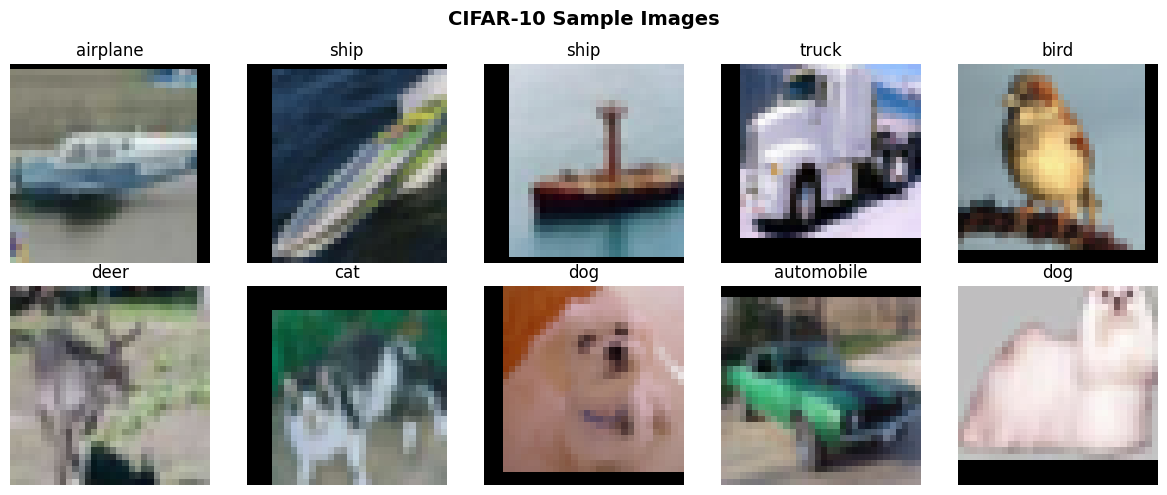

✅ Sample images displayed!


In [3]:
# Cell 3 — Visualize Sample Images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR-10 Sample Images', fontsize=14, fontweight='bold')

# Get one batch
images, labels = next(iter(train_loader))

for i, ax in enumerate(axes.flat):
    # Unnormalize
    img = images[i].numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    
    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis('off')

plt.tight_layout()
plt.savefig('../data/processed/cifar10_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample images displayed!")

In [4]:
# Cell 4 — Build ResNet18 Model (Transfer Learning)
# Load pretrained ResNet18
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all layers except the last one
for param in model.parameters():
    param.requires_grad = False

# Replace final layer for 10 classes (CIFAR-10)
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 10)
)

# Move to device
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✅ ResNet18 model built!")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")
print("\nModel architecture (final layer):")
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\varsh/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:09<00:00, 4.85MB/s]

✅ ResNet18 model built!
Total parameters:     11,310,410
Trainable parameters: 133,898
Frozen parameters:    11,176,512

Model architecture (final layer):
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=10, bias=True)
)


In [5]:
# Cell 5 — Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss/len(loader), correct/total

def eval_epoch(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            correct += (model(images).argmax(1) == labels).sum().item()
            total += labels.size(0)
    return correct/total

print("✅ Training setup done!")
print("Optimizer: AdamW")
print("Scheduler: StepLR")
print("Loss: CrossEntropyLoss")

✅ Training setup done!
Optimizer: AdamW
Scheduler: StepLR
Loss: CrossEntropyLoss


In [6]:
# Cell 6 — Train the Model
print("🚀 Starting training...")
print("⚠️  This takes 10-15 mins on CPU — don't close VS Code!\n")

history = []
best_val_acc = 0
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_acc = eval_epoch(model, val_loader)
    scheduler.step()
    
    history.append({
        'epoch': epoch+1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    })
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '../models/saved/resnet18_cifar10.pt')
    
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

print(f"\n✅ Training complete!")
print(f"🏆 Best Validation Accuracy: {best_val_acc:.4f}")

🚀 Starting training...
⚠️  This takes 10-15 mins on CPU — don't close VS Code!

Epoch 1/5 | Loss: 1.8933 | Train: 0.3207 | Val: 0.3921
Epoch 2/5 | Loss: 1.8097 | Train: 0.3525 | Val: 0.3894
Epoch 3/5 | Loss: 1.7930 | Train: 0.3614 | Val: 0.3929
Epoch 4/5 | Loss: 1.7672 | Train: 0.3708 | Val: 0.4065
Epoch 5/5 | Loss: 1.7450 | Train: 0.3773 | Val: 0.4082

✅ Training complete!
🏆 Best Validation Accuracy: 0.4082


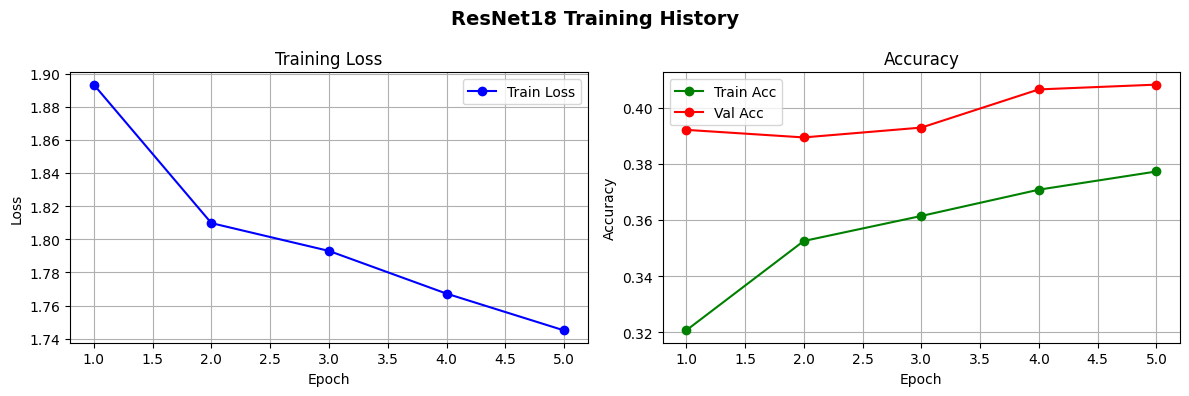

✅ Training history plotted and saved!


In [8]:
# Cell 7 — Plot Training History
import pandas as pd

history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('ResNet18 Training History', fontsize=14, fontweight='bold')

# Plot Loss
axes[0].plot(history_df['epoch'], history_df['train_loss'], 'b-o', label='Train Loss')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Plot Accuracy
axes[1].plot(history_df['epoch'], history_df['train_acc'], 'g-o', label='Train Acc')
axes[1].plot(history_df['epoch'], history_df['val_acc'], 'r-o', label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../data/processed/cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training history plotted and saved!")

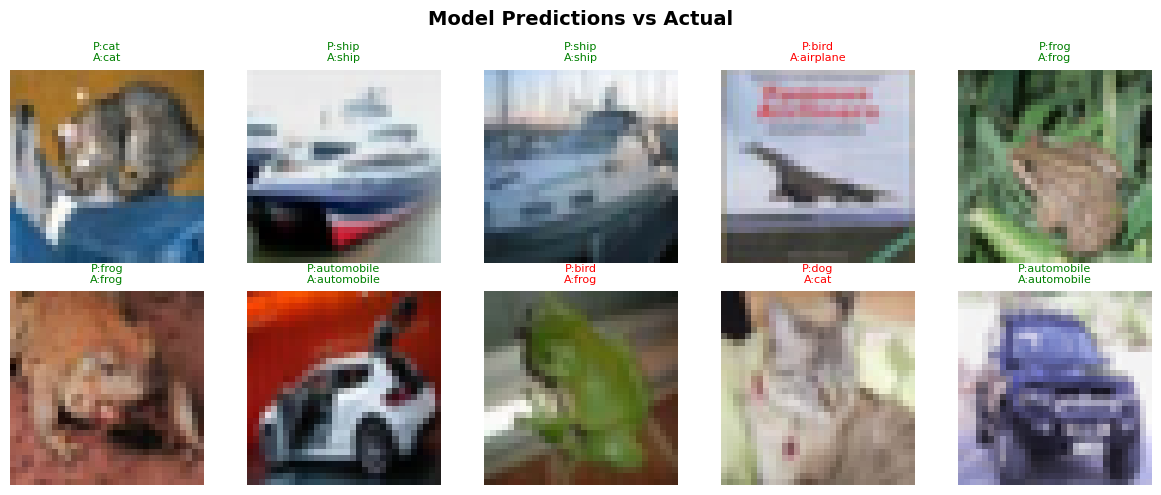

✅ Predictions plotted! Green=Correct, Red=Wrong


In [9]:
# Cell 8 — Test Model on Sample Images
model.eval()

# Get a batch of test images
test_images, test_labels = next(iter(val_loader))
test_images, test_labels = test_images.to(device), test_labels.to(device)

# Get predictions
with torch.no_grad():
    outputs = model(test_images)
    predictions = outputs.argmax(1)

# Plot 10 sample predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Model Predictions vs Actual', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = test_images[i].cpu().numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    
    pred = classes[predictions[i]]
    actual = classes[test_labels[i]]
    color = 'green' if pred == actual else 'red'
    
    ax.imshow(img)
    ax.set_title(f'P:{pred}\nA:{actual}', color=color, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../data/processed/cnn_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Predictions plotted! Green=Correct, Red=Wrong")